In [1]:
import insilicoICH
insilicoICH.available_phantoms

[0,
 1.0,
 2.0,
 6.5,
 9.0,
 10.5,
 11.5,
 12.0,
 15.75,
 38,
 'ACRPhantom',
 'DensitometryPhantom',
 'LowContrastDetectabilityPhantom',
 'WirePhantom']

In [2]:
from insilicoICH import load_phantom
age = 0.0
print('loading phantom, age ' + str(age))
phantom_neo = load_phantom(age)
age = 1.0
print('loading phantom, age ' + str(age))
phantom_1 = load_phantom(age)
age = 2.0
print('loading phantom, age ' + str(age))
phantom_2 = load_phantom(age)


from utils import scrollview
scrollview(phantom_neo.get_CT_number_phantom(), display='soft tissues')

loading phantom, age 0.0
loading phantom, age 1.0
loading phantom, age 2.0


interactive(children=(IntSlider(value=90, description='idx', max=180), Output()), _dom_classes=('widget-intera…

Text(0.5, 0.98, 'UNC Otsu Thresholding')

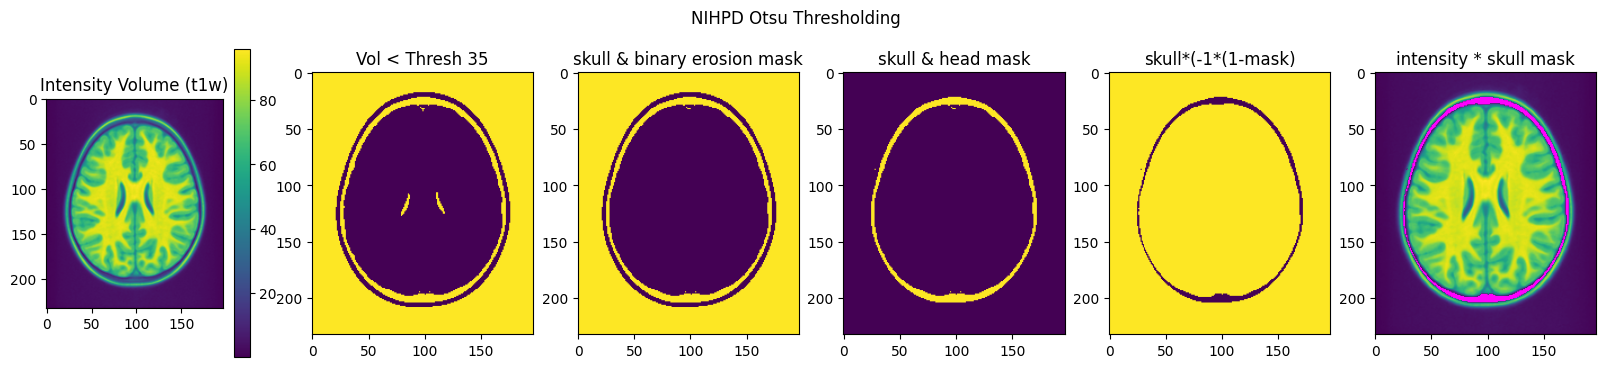

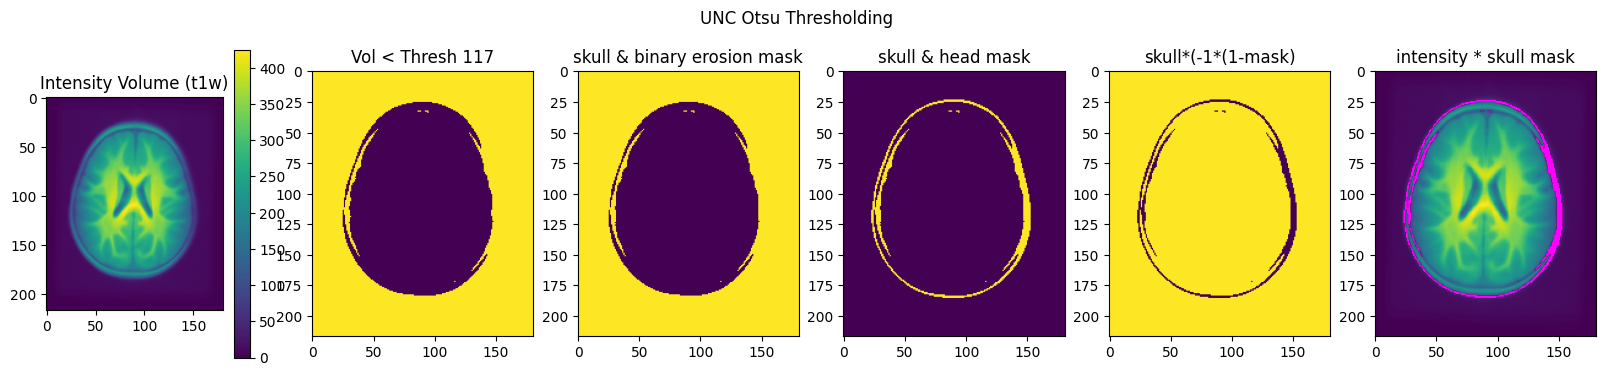

In [ ]:
# CHECK NIHPD OTSU (untouched from phantoms.py)
NIHPD_Phantom = load_phantom(6.5)
import skimage as ski
import numpy as np
import matplotlib.pyplot as plt
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(20,4))
vol = NIHPD_Phantom.t1w
plt1 = axs[0].imshow(vol[90, :, :])
axs[0].set_title('Intensity Volume (t1w)')
plt.colorbar(plt1, ax=axs[0])
thresh = 35.61893018554474  # precalculated by performing otsu across all nihpd
skull = vol < thresh
axs[1].imshow(skull[90, :, :])
axs[1].set_title(f'Vol < Thresh {int(thresh)}')
skull = skull & ~ski.morphology.binary_erosion(NIHPD_Phantom.mask, np.ones(3*[3]))
axs[2].imshow(skull[90, :, :])
axs[2].set_title('skull & binary erosion mask')
skull = skull & NIHPD_Phantom.head_mask
axs[3].imshow(skull[90, :, :])
axs[3].set_title('skull & head mask')
skull = skull*(-1*(1-NIHPD_Phantom.mask))
axs[4].imshow(skull[90, :, :])
axs[4].set_title('skull*(-1*(1-mask)')
skull_mask = np.ma.masked_where(skull == 0, skull)
axs[5].imshow(vol[90, :, :])
axs[5].imshow(skull_mask[90, :, :], alpha=1.0, cmap='cool_r')
axs[5].set_title('intensity * skull mask')
plt.suptitle('NIHPD Otsu Thresholding')

# CHECK UNC OTSU
UNC_Phantom = load_phantom(1.0)
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(20,4))
vol = UNC_Phantom.intensity
plt1 = axs[0].imshow(vol[90, :, :])
axs[0].set_title('Intensity Volume (t1w)')
plt.colorbar(plt1, ax=axs[0])
thresh = ski.filters.threshold_otsu(vol)
skull = vol < thresh
axs[1].imshow(skull[90, :, :])
axs[1].set_title(f'Vol < Thresh {int(thresh)}')
skull = skull & ~ski.morphology.binary_erosion(UNC_Phantom.mask, np.ones(3*[3]))
axs[2].imshow(skull[90, :, :])
axs[2].set_title('skull & binary erosion mask')
skull = skull & UNC_Phantom.head_mask
axs[3].imshow(skull[90, :, :])
axs[3].set_title('skull & head mask')
skull = skull*(-1*(1-UNC_Phantom.mask))
axs[4].imshow(skull[90, :, :])
axs[4].set_title('skull*(-1*(1-mask)')
skull_mask = np.ma.masked_where(skull == 0, skull)
axs[5].imshow(vol[90, :, :])
axs[5].imshow(skull_mask[90, :, :], alpha=1.0, cmap='cool_r')
axs[5].set_title('intensity * skull mask')
plt.suptitle('UNC Otsu Thresholding')

In [ ]:

# # otsu testing
# import skimage as ski
# import numpy as np
# vol = phantom_1.intensity
# print(vol.shape)

# # copy-pasted from NIHPD
# thresh = ski.filters.threshold_otsu(vol*phantom_1.head_mask) # TODO: SEPARATE THRESHOLD FOR AGE 0, Otsu not working well
# thresh = 160
# print(thresh)
# skull = (vol*phantom_1.head_mask) < thresh
# skull = skull & ~ski.morphology.binary_erosion(phantom_1.mask, np.ones(3*[3]))
# skull = skull & phantom_1.head_mask
# skull = skull*(-1*(1-phantom_1.mask)) * phantom_1.head_mask

# import matplotlib.pyplot as plt
# fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(10,5))
# axs[0].imshow(vol[90, :, :])
# axs[1].imshow(skull[90, :, :])
# axs[2].imshow(vol[90, :, :])
# axs[2].imshow(skull[90, :, :], alpha=0.5)
# axs[3].imshow(phantom_1.head_mask[90, :, :])
# axs[4].imshow(phantom_1.mask[90, :, :])

# fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(10,5))
# axs[0].imshow(vol[150, :, :])
# axs[1].imshow(skull[150, :, :])
# axs[2].imshow(vol[150, :, :])
# axs[2].imshow(skull[150, :, :], alpha=0.5)
# axs[3].imshow(phantom_1.head_mask[150, :, :])
# axs[4].imshow(phantom_1.mask[150, :, :])

# scrollview(vol)


In [ ]:
# import matplotlib.pyplot as plt

# fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
# axs[0].imshow(phantom_neo.head_mask[90, :, :])
# axs[0].set_title('head mask')
# axs[1].imshow(phantom_neo.mask[90, :, :])
# axs[1].set_title('mask')
# axs[2].imshow(phantom_neo._phantom[90, :, :], vmin=0, vmax=80)
# axs[2].set_title('image')

# fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
# axs[0].imshow(phantom_1.head_mask[90, :, :])
# axs[0].set_title('head mask')
# axs[1].imshow(phantom_1.mask[90, :, :])
# axs[1].set_title('mask')
# axs[2].imshow(phantom_1._phantom[90, :, :], vmin=0, vmax=80)
# axs[2].set_title('image')

# fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
# axs[0].imshow(phantom_2.head_mask[90, :, :])
# axs[0].set_title('head mask')
# axs[1].imshow(phantom_2.mask[90, :, :])
# axs[1].set_title('mask')
# axs[2].imshow(phantom_2._phantom[90, :, :], vmin=0, vmax=80)
# axs[2].set_title('image')

In [ ]:
# phantom_neo = load_phantom(age)
# scrollview(phantom_neo.get_CT_number_phantom(), display='soft tissues')

In [ ]:
# ages = [0, 1.0, 2.0]
# subtypes = ['IPH', 'EDH', 'SDH']

# idx = 0
# fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10,10))
# for x, age in enumerate(ages):
#     for y, subtype in enumerate(subtypes):
#         print(f'inserting {subtype} into UNC age {age} phantom')
#         phantom = load_phantom(age)
#         if subtype == 'SDH': 
#             volume=10
#         else: 
#             volume=5
#         phantom.insert_lesion(subtype, mass_effect=True, intensity=80, volume=volume)
#         axs[x, y].imshow(phantom._phantom[90, :, :], vmin=0, vmax=80)
#         idx += 1